In [829]:
from matplotlib import pyplot as plt
import numpy as np
import math
from value import Value

In [830]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.children:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{  %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n.op:
            dot.node(name=str(id(n)) + n.op, label=n.op)
            dot.edge(str(id(n)) + n.op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2.op)
    
    return dot


In [831]:
class Value:
    def __init__(self, data, children = () , op = '') -> None:
        self.data = data
        self.children = children
        self.op = op
        self.label = ""
        self.grad = 0.0
        self._backward = lambda : None
        
    def add_label(self, label):
        self.label = label
    
    def __repr__(self) -> str:
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if not isinstance(other, (int, float)) else Value(other)
        out = Value(self.data + other.data , (self,other), '+' )
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        
        out._backward = _backward
        return out
        
    def __radd__(self, other):
        return self + other
    
    def __mul__(self, other):
        other = other if not isinstance(other, (int, float)) else Value(other) 
        
        out = Value(self.data * other.data , (self,other), '*' )
        
        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        
        out._backward = _backward
        return out
        

    def __rmul__(self, other):
        return self * other
    
    def exp(self):
        o = (math.exp(2*self.data) - 1) / (math.exp(2*self.data) + 1)
        out = Value(o, children=(self,), op="tanh")
        def _backward():
            self.grad += (1-(o**2)) * out.grad
            
        out._backward = _backward
        return out
    
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out
    
    def __neg__(self):
        return self * (-1)
        
    
    def __sub__(self, other):
        return self + (-other)
    
    def backward(self):
        vis = set()
        topo = []
        
        def build_topo(node):
            if node not in vis:
                vis.add(node)
            
            for child in node.children:
                build_topo(child)
            
            topo.append(node)
        build_topo(self)
        
        self.grad = 1.0
        
        for ele in reversed(topo):
            ele._backward()
        

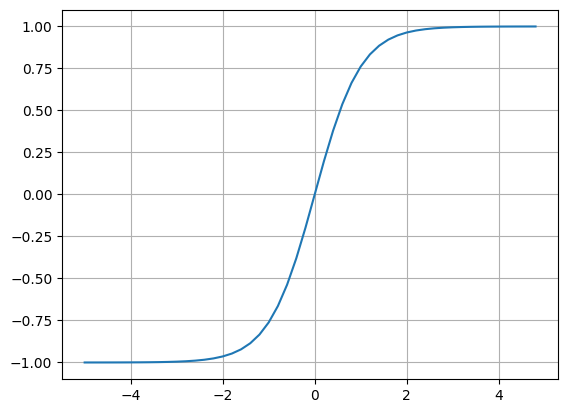

In [832]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2)))
plt.grid()

In [833]:
# forward pass

x1 = Value(2.0)
x1.add_label("x1")
x2 = Value(0.0)
x2.add_label("x2")

b0 = Value(6.8813735870195432)
b0.add_label("b0")

b1 = Value(-3.0)
b1.add_label("w1")
b2 = Value(1.0)
b2.add_label("w2")



x1b1 = x1*b1
x1b1.add_label("x1b1")
x2b2 = x2*b2
x2b2.add_label("x2b2")

x1b1x2b2 = x1b1 + x2b2
x1b1x2b2.add_label("x1b1x2b2")

s= x1b1x2b2 + b0
s.add_label("s")

tanh = s.exp()
tanh.add_label("tanh")
tanh.backward()

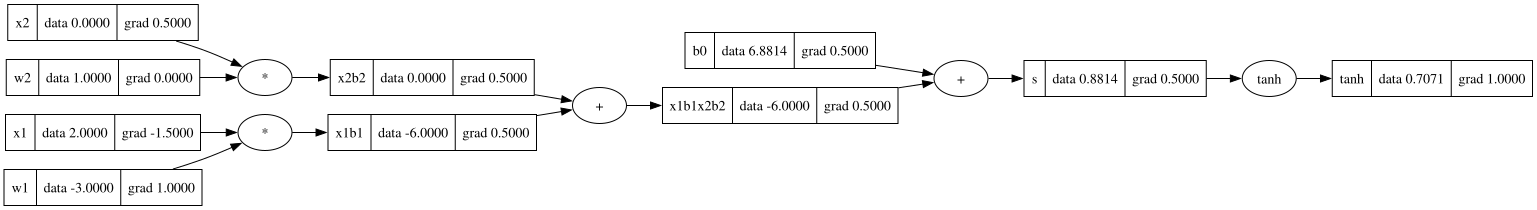

In [834]:
draw_dot(tanh)

# How can i do the same above using pytorch

In [835]:
import torch

In [836]:
x1 = torch.Tensor([2.0]).double()
x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()
x2.requires_grad = True

w1 = torch.Tensor([-3.0]).double()
w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()
w2.requires_grad = True

b = torch.Tensor([6.8813735870195432]).double()
b.requires_grad = True

In [837]:
n = b + ( (x1*w1) + (x2*w2))
o = torch.tanh(n)

In [838]:
o.backward()

In [839]:
print(x1.grad.item())
print(w1.grad.item())
print(x2.grad.item())
print(w2.grad.item())

print(b.grad.item())

-1.5000003851533106
1.0000002567688737
0.5000001283844369
0.0
0.5000001283844369


In [840]:
o.data.item()

0.7071066904050358

# Single Neuron --> Single Layer ---> Multi Layer

In [841]:
import random
from typing import Any
# A single neuron
# nin Number of inputs

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        self.nin = nin
    def __call__(self, x) -> Any:
        act:Value = sum( [w*v for w, v in zip(self.w, x)] , self.b )
        out = act.exp()
        return out

    def parameters(self):
        return self.w + [self.b]
    
    

# A collection of Neurons
# nin Number of inputs for a single neuron
# nneu Number of neurons

class Layer:
    def __init__(self, nin , nneu) -> None:
        self.neurons = [Neuron(nin) for _ in range(nneu)]
        
    def __call__(self, x) -> Any:
        out = [ neu(x) for neu in self.neurons]
        return out if len(out) != 1 else out[0]
    
    def parameters(self):
        params = []
        
        for neu in self.neurons:
            params.extend(neu.parameters())
        return params
    
# Multi layer perceptron
# nin is int and it tells number of inputs
# nnl is list number of neurons in each layer

class MLP:
    def __init__(self, nin, nnl):
        # Combine the inputs and nnl 
        self.total = [nin] + nnl
        
        # Number of inputs we get for each neuron is like prev layer neurons --> next layer neurons
        self.layers = [ Layer(self.total[i], self.total[i+1]) for i in range(len(nnl))]
    
    def __call__(self,x) -> Any:
        for l in self.layers:
            x = l(x)
        return x
    
    def parameters(self):
        p = []
        for layer in self.layers:
            p.extend(layer.parameters())
        return p
        

v = MLP(3, [4, 4, 1])

In [842]:
# Data defination
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
      ]
out = [1.0, -1.0, -1.0, 1.0]

In [845]:
w = [Value(random.uniform(-1,1)) for _ in range(3)]

In [719]:
# Graident Descent 
# Forwardpass --> Backward pass ---> update params

In [823]:

for k in range(20):
    # Forward Pass
    ypred = [v(inp) for inp in xs]
    loss = sum([(yprd - yorg)**2 for yorg, yprd in zip(out, ypred)])
    
    # flush the gradients to 0 or else this will keep on accumulating in every iteration
    for p in v.parameters():
        p.grad = 0
    
    # Backward Pass
    loss.backward()

    # Tweeking the parametrs to minimize the loss
    for p in v.parameters():
        p.data += -0.01 * p.grad
        
    print(f"setp {k} and loss = {loss}")

setp 0 and loss = Value(data=0.0006027165556852467)
setp 1 and loss = Value(data=0.000602613436500547)
setp 2 and loss = Value(data=0.0006025103521614586)
setp 3 and loss = Value(data=0.000602407302650427)
setp 4 and loss = Value(data=0.0006023042879498984)
setp 5 and loss = Value(data=0.0006022013080423135)
setp 6 and loss = Value(data=0.0006020983629101396)
setp 7 and loss = Value(data=0.0006019954525358579)
setp 8 and loss = Value(data=0.0006018925769019521)
setp 9 and loss = Value(data=0.0006017897359909393)
setp 10 and loss = Value(data=0.0006016869297853058)
setp 11 and loss = Value(data=0.0006015841582675972)
setp 12 and loss = Value(data=0.000601481421420339)
setp 13 and loss = Value(data=0.0006013787192260853)
setp 14 and loss = Value(data=0.0006012760516673845)
setp 15 and loss = Value(data=0.0006011734187268214)
setp 16 and loss = Value(data=0.000601070820386966)
setp 17 and loss = Value(data=0.000600968256630427)
setp 18 and loss = Value(data=0.0006008657274397941)
setp 19 

In [824]:
out

[1.0, -1.0, -1.0, 1.0]

In [825]:
ypred

[Value(data=0.988171162124976),
 Value(data=-0.9870992600983848),
 Value(data=-0.988110383275234),
 Value(data=0.987628672203311)]

In [ ]:
# final paramerts which are very good after training the neural net
v.parameters()

[Value(data=-0.8244629056875868),
 Value(data=1.515945245897384),
 Value(data=-3.4493092014398314),
 Value(data=-1.578177277175509),
 Value(data=0.7458995297220576),
 Value(data=3.2312258069377653),
 Value(data=-8.70861760523244),
 Value(data=0.8730062744979903),
 Value(data=-1.62895887306375),
 Value(data=-5.131348540590497),
 Value(data=2.442734999800065),
 Value(data=-1.2308302530696469),
 Value(data=1.9557935663418637),
 Value(data=3.03741036609245),
 Value(data=-1.8222210659983646),
 Value(data=2.26092677889438),
 Value(data=0.509540306809103),
 Value(data=0.25094524287425934),
 Value(data=-0.5282541813098242),
 Value(data=0.26987574724783453),
 Value(data=0.8992013731627785),
 Value(data=-1.3600679440196437),
 Value(data=-0.657206315962869),
 Value(data=-0.37725789155561146),
 Value(data=0.42814377675531134),
 Value(data=-0.4056875438511607),
 Value(data=0.7140327355808004),
 Value(data=0.6183922359933739),
 Value(data=-0.296377514829416),
 Value(data=0.6895964048804236),
 Value(